In [2]:
from pathlib import Path

import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette(),)
import polars as pl
import duckdb

In [3]:
duckdb.sql("""
attach 'runs.sqlite';
use runs;
""")

In [29]:
fk_steering_rows = duckdb.sql("""
select
    *
from Conf
where true
and num_inference_steps = 50
and num_particles >= 2 and num_particles <= 32
""")
fk_steering_rows.show(max_width=120)

┌──────────┬──────────┬──────────────────────┬───┬────────────────┬───────┬────────┬─────────────────────┐
│  alt_id  │ rng_seed │      model_name      │ … │ sa_inheritance │  id   │ Prompt │ adaptive_resampling │
│ varchar  │  int64   │       varchar        │   │    varchar     │ int64 │ int64  │        int64        │
├──────────┼──────────┼──────────────────────┼───┼────────────────┼───────┼────────┼─────────────────────┤
│ 09o8006u │ 88422417 │ CompVis/stable-dif…  │ … │ Conf           │   723 │     73 │                   0 │
│ g6oljoaz │ 88422417 │ CompVis/stable-dif…  │ … │ Conf           │   724 │     93 │                   0 │
│ k09425t1 │ 21021095 │ CompVis/stable-dif…  │ … │ Conf           │   725 │     11 │                   0 │
│ 635vjm30 │ 88422417 │ CompVis/stable-dif…  │ … │ Conf           │   726 │     11 │                   0 │
│ n4ocrpy6 │ 21021095 │ CompVis/stable-dif…  │ … │ Conf           │   727 │     73 │                   0 │
│ c5s15pxg │ 25839091 │ CompVis/stabl

In [31]:
fk_steering = (
    pl.scan_csv([
        path
        for alt_id, in duckdb.sql("select alt_id from fk_steering_rows").fetchall()
        if (path := Path(f'/home/ttransue/GitHub/Fk-Diffusion-Steering/text_to_image/outputs/runs/{alt_id}/metrics_best_sample.csv')).exists()
    ], include_file_paths='file_path')
    .with_columns(alt_id=pl.col('file_path').str.split('/').list.get(-2))
    .collect()
)
fk_steering = duckdb.sql("""
select
    'FeynmannKac' as steering,
    rng_seed,
    prompt_id,
    num_particles,
    adaptive_resampling,
    ImageReward
from fk_steering
join fk_steering_rows on fk_steering.alt_id = fk_steering.alt_id
""")
fk_steering.show(max_width=120)

┌─────────────┬──────────┬─────────────┬───────────────┬─────────────────────┬─────────────────────┐
│  steering   │ rng_seed │  prompt_id  │ num_particles │ adaptive_resampling │     ImageReward     │
│   varchar   │  int64   │   varchar   │     int64     │        int64        │       double        │
├─────────────┼──────────┼─────────────┼───────────────┼─────────────────────┼─────────────────────┤
│ FeynmannKac │ 88422417 │ 010525-0074 │             2 │                   0 │  0.7529383301734924 │
│ FeynmannKac │ 88422417 │ 010525-0074 │             2 │                   0 │  0.7529383301734924 │
│ FeynmannKac │ 21021095 │ 010525-0074 │             2 │                   0 │  0.7529383301734924 │
│ FeynmannKac │ 88422417 │ 010525-0074 │             2 │                   0 │  0.7529383301734924 │
│ FeynmannKac │ 21021095 │ 010525-0074 │             2 │                   0 │  0.7529383301734924 │
│ FeynmannKac │ 25839091 │ 010525-0074 │             2 │                   0 │  0.752938330

In [33]:
duckdb.sql("""
select
    prompt_id,
    num_particles as chain_count,
    adaptive_resampling,
    mean(ImageReward),
from fk_steering
group by num_particles, prompt_id, adaptive_resampling
order by num_particles, prompt_id, adaptive_resampling
limit 20;
""")

┌─────────────┬─────────────┬─────────────────────┬──────────────────────┐
│  prompt_id  │ chain_count │ adaptive_resampling │  mean(ImageReward)   │
│   varchar   │    int64    │        int64        │        double        │
├─────────────┼─────────────┼─────────────────────┼──────────────────────┤
│ 000969-0041 │           2 │                   0 │  0.07240158831700683 │
│ 000969-0041 │           2 │                   1 │  0.07240158831700683 │
│ 001227-0027 │           2 │                   0 │   1.8106922157108785 │
│ 001227-0027 │           2 │                   1 │   1.8106922157108785 │
│ 001251-0073 │           2 │                   0 │   0.0186127167660743 │
│ 001251-0073 │           2 │                   1 │   0.0186127167660743 │
│ 005895-0048 │           2 │                   0 │ -0.16351036259438842 │
│ 005895-0048 │           2 │                   1 │ -0.16351036259438842 │
│ 005903-0142 │           2 │                   0 │   1.1479102794080973 │
│ 005903-0142 │          

In [5]:
# fk_steering = (
#     pl.scan_csv('/home/ttransue/GitHub/Fk-Diffusion-Steering/text_to_image/outputs/runs/*/metrics_best_sample.csv')
#     .select(pl.lit('FeynmannKac').alias('steering'), 'prompt_id', 'ImageReward')
# )
spt_steering = (
    pl.scan_csv('spt_image_rewards.csv')
    .select(
        steering=pl.col('steering') + ' (' + pl.col('update_count').cast(str) + ')',
        prompt_id='prompt_id',
        ImageReward='ImageReward',
    )
    .collect()
)
data = pl.concat([fk_steering.pl(), spt_steering])

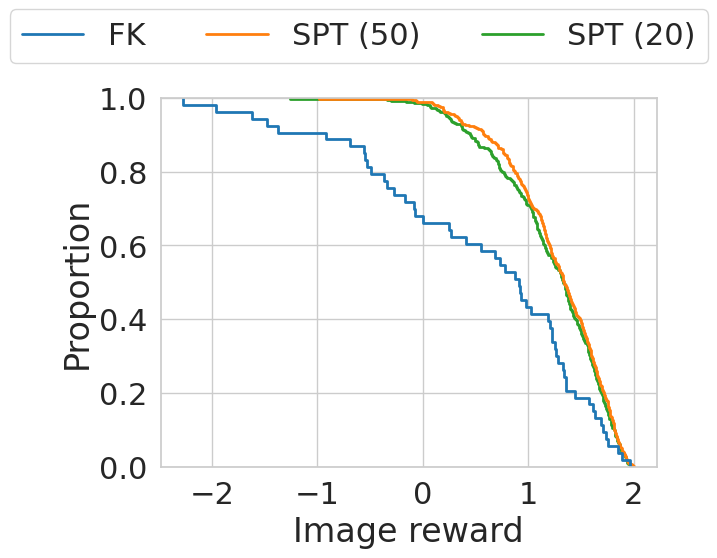

In [6]:
plot = (
    sns.ecdfplot(
        data=data,
        # stat='percent',
        x='ImageReward',
        hue='steering',
        hue_order=['FeynmannKac', 'SourceParallelTempering (50)', 'SourceParallelTempering (20)',],
        linewidth=2,
        complementary=True,
    )
)
plot.set_xlabel('Image reward')
sns.move_legend(
    plot,
    loc='upper center',
    labels=['FK', 'SPT (50)', 'SPT (20)',],
    ncol=4,
    title='',
    bbox_to_anchor=(.400, 1.28),
    frameon=True,
    fancybox=True,
)